# EfficientNet-B3 Augmented — Focal Loss

## Changes from EfficientNet-B3 Augmented Baseline

### What changed
| | EfficientNet-B3 Augmented | EfficientNet-B3 Augmented + Focal Loss |
|---|---|---|
| Loss function | `BCEWithLogitsLoss(pos_weight=6.02)` | `BinaryFocalLoss(alpha=0.75, gamma=2.0)` |
| Class imbalance handling | Static scalar `pos_weight` | Dynamic per-example weighting via `alpha` + `gamma` |

### Rationale
Focal Loss replaces the static `pos_weight` reweighting with a dynamic weighting `(1 - p_t)^gamma` that suppresses gradients from easy examples (confidently correct predictions) and focuses training on hard ones. The `alpha=0.75` parameter replaces `pos_weight` for class-level reweighting — stacking both would double-count the imbalance correction.

Everything else is identical to the best test F2 baseline: AdamW + CosineAnnealingLR + strong augmentation at 300×300.

### Baseline to beat
| Metric | EfficientNet-B3 Augmented |
|---|---|
| Test Accuracy | 0.8934 |
| Test F2 | 0.8072 |
| Test Recall | 0.8623 |
| Test Precision | 0.5854 |

In [7]:
# --- Focal Loss Config ---
ALPHA = 0.75   # weight for positive class (melanoma); replaces pos_weight
GAMMA = 2.0    # focusing parameter; 0.0 reduces to weighted BCE
NUM_EPOCHS = 20
BATCH_SIZE = 32
IMAGE_SIZE = 300
LR = 1e-4
WEIGHT_DECAY = 1e-4
MODEL_SAVE_PATH = '../../models/efficientnet_b3_augment_focal_best.pth'

In [8]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

import pandas as pd

import torch
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.training.losses import BinaryFocalLoss

In [9]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    elif torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)

In [10]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [11]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../../data/splits/train.csv',
    val_csv='../../data/splits/val.csv',
    test_csv='../../data/splits/test.csv',
    image_dir='../../data/raw/HAM10000/images',
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    num_workers=0,
    transform_train=get_augmented_train_transforms(image_size=IMAGE_SIZE),
)

model = get_efficientnet(num_classes=1, freeze_backbone=False).to(device)
criterion = BinaryFocalLoss(alpha=ALPHA, gamma=GAMMA)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f'Focal Loss: alpha={ALPHA}, gamma={GAMMA}')

Focal Loss: alpha=0.75, gamma=2.0


In [12]:
best_val_f2 = 0.0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_recalls, val_recalls = [], []
train_f2s, val_f2s = [], []

for epoch in range(NUM_EPOCHS):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f'  Saved best model at epoch {epoch+1}')

Epoch [1/20] | Train Loss: 0.0347, Acc: 0.8236, Recall: 0.6778, F2: 0.6058 | Val Loss: 0.0289, Acc: 0.8670, Recall: 0.7784, F2: 0.7088
  Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.0280, Acc: 0.8635, Recall: 0.7664, F2: 0.6978 | Val Loss: 0.0278, Acc: 0.8542, Recall: 0.8144, F2: 0.7203
  Saved best model at epoch 2


Epoch [3/20] | Train Loss: 0.0260, Acc: 0.8798, Recall: 0.7831, F2: 0.7236 | Val Loss: 0.0263, Acc: 0.8934, Recall: 0.7904, F2: 0.7416
  Saved best model at epoch 3


Epoch [4/20] | Train Loss: 0.0237, Acc: 0.8916, Recall: 0.8010, F2: 0.7468 | Val Loss: 0.0258, Acc: 0.8755, Recall: 0.8503, F2: 0.7626
  Saved best model at epoch 4


Epoch [5/20] | Train Loss: 0.0213, Acc: 0.9026, Recall: 0.8293, F2: 0.7761 | Val Loss: 0.0257, Acc: 0.9173, Recall: 0.7605, F2: 0.7453


...

Epoch [16/20] | Train Loss: 0.0087, Acc: 0.9662, Recall: 0.9435, F2: 0.9206 | Val Loss: 0.0345, Acc: 0.9113, Recall: 0.7605, F2: 0.7392


Epoch [17/20] | Train Loss: 0.0089, Acc: 0.9655, Recall: 0.9487, F2: 0.9228 | Val Loss: 0.0357, Acc: 0.9079, Recall: 0.7844, F2: 0.7520


Epoch [18/20] | Train Loss: 0.0077, Acc: 0.9693, Recall: 0.9576, F2: 0.9332 | Val Loss: 0.0370, Acc: 0.9156, Recall: 0.7485, F2: 0.7353


Epoch [19/20] | Train Loss: 0.0081, Acc: 0.9691, Recall: 0.9422, F2: 0.9235 | Val Loss: 0.0374, Acc: 0.9156, Recall: 0.7485, F2: 0.7353


Epoch [20/20] | Train Loss: 0.0085, Acc: 0.9655, Recall: 0.9487, F2: 0.9228 | Val Loss: 0.0356, Acc: 0.9088, Recall: 0.7784, F2: 0.7488


## Plot Loss and Accuracy Curves

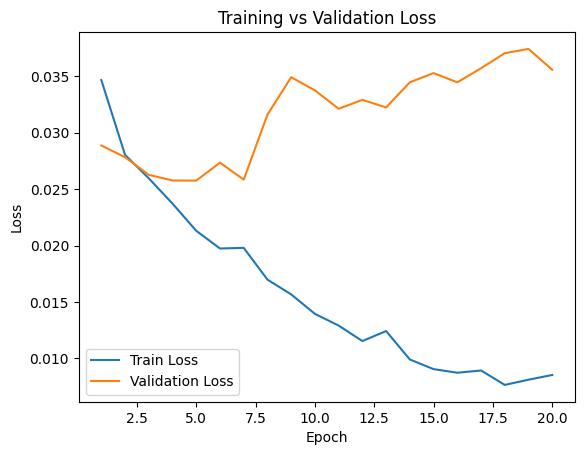

In [13]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

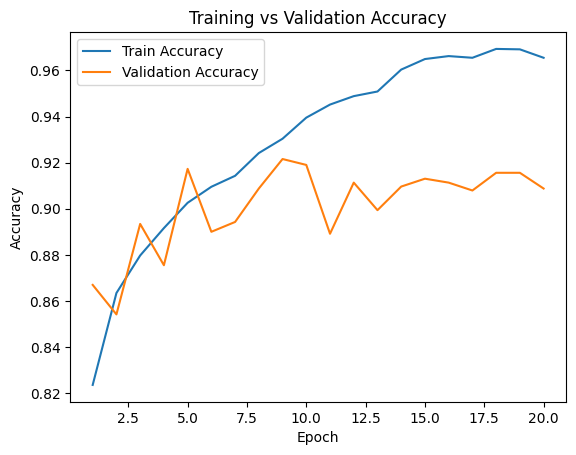

In [14]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

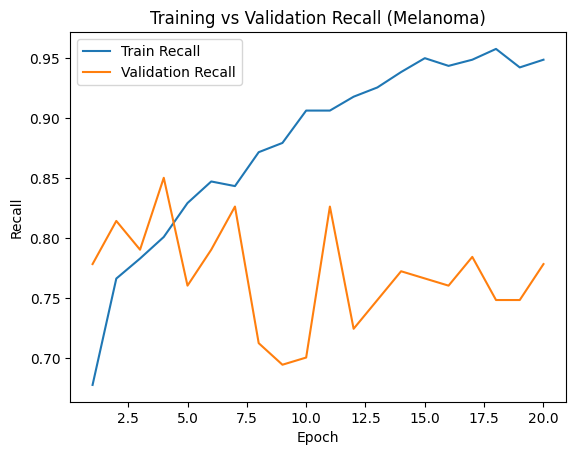

In [15]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

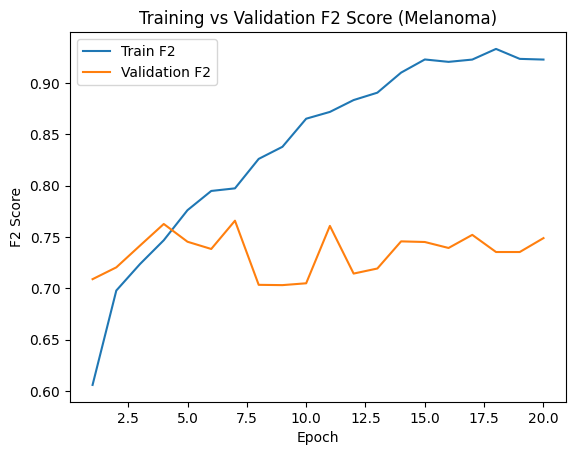

In [16]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

## Threshold Tuning

In [17]:
from sklearn.metrics import fbeta_score

model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}')

Best threshold: 0.50 | Val F2: 0.7658


In [18]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [19]:
cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[914  92]
 [ 26 141]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [20]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9723    0.9085    0.9394      1006
           1     0.6052    0.8443    0.7050       167

    accuracy                         0.8994      1173
   macro avg     0.7887    0.8764    0.8222      1173
weighted avg     0.9201    0.8994    0.9060      1173



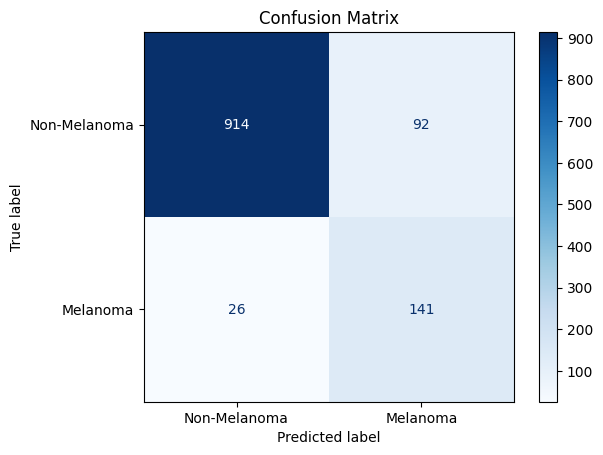

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()